# The Robert and Rosenbaum Uncertainty Zones model

## Implementation by 
## Marcos Costa Santos Carreira
## École Polytechnique - CMAP
## Feb-2020

### Import packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as st
import seaborn as sns

In [2]:
from functools import partial

In [3]:
from scipy import optimize

In [824]:
from scipy.special import kv

In [4]:
import datetime as dtt

In [5]:
import numba as numba

In [6]:
from math import erfc

### Define functions

In [477]:

@numba.jit(nopython=True)
def nprobw(ud, s0, s, α, η, σ, μ, t):
    if t == 0:
        ans = 0
    else:
        ω = μ - 0.5 * σ ** 2
        x0 = np.log(s0)
        bu = np.log(s + (0.5 + η) * α)
        bd = np.log(s - (0.5 + η) * α)
        bpm = bu * (1 + ud) / 2 + bd * (1 - ud) / 2
        bmp = bu * (1 - ud) / 2 + bd * (1 + ud) / 2
        tyzn = 0
        n = 0
        tyznn = 1
        eps=1e-16
        while tyznn > eps:
            n += 1
            yn = ud * (2 * (n - 1) * bmp - (2 * n - 1) * bpm + x0)
            zn = ud * (2 * n * bmp - (2 * n - 1) * bpm - x0)
            tyznn =\
                (np.exp(ω * yn / (σ ** 2)) * erfc(
                -(yn + ω * t) / (σ * np.sqrt(2 * t))) -
                np.exp(ω * zn / (σ ** 2)) * erfc(
                -(zn + ω * t) / (σ * np.sqrt(2 * t))) +
                np.exp(-ω * yn / (σ ** 2)) * erfc(
                -(yn - ω * t) / (σ * np.sqrt(2 * t))) -
                np.exp(-ω * zn / (σ ** 2)) * erfc(
                -(zn - ω * t) / (σ * np.sqrt(2 * t)))) / 2
            tyzn += tyznn
        ans = np.exp(ω * (bpm - x0) / (σ ** 2)) * tyzn
    return ans

In [478]:
print('start')
currentDT1 = dtt.datetime.now()
print (str(currentDT1))

print(nprobw(1, 100, 100, 0.001, 0.25, 0.01, 0, 1))

print('end')
currentDT2 = dtt.datetime.now()
print (str(currentDT2))

print (str(currentDT2 - currentDT1))

start
2020-09-21 20:28:33.608928
0.5000000000334976
end
2020-09-21 20:28:33.900354
0:00:00.291426


In [337]:
def t_from_pw(ud, s0, s, α, η, σ, μ):
    '''t_from_pw(ud, s0, s, α, η, σ, μ) solves the equation
    Pup(t) / Pup(1) (or Pdown(t) / Pdown(1))  = p;
    so for a random p such that 0 <= p <= 1 we find
    the expected time of a price change for the sign given'''
    mprobt = partial(nprobw, ud, s0, s, α, η, σ, μ)
    def groot0(t):
            return -mprobt(t)
    sol0 = optimize.minimize_scalar(groot0, bracket=[0, 1], method='golden')
    return sol0

In [9]:
def drawfromp(ud, s0, s, α, η, σ, μ, n=10000):
    '''drawfromp(ud, s0, s, α, η, σ, μ, n=100) solves the equation
    Pup(t) / Pup(1) (or Pdown(t) / Pdown(1))  = p;
    so for a random p such that 0 <= p <= 1 we find
    the expected time of a price change for the sign given'''
    mprobt = partial(nprobw, ud, s0, s, α, η, σ, μ)
    ts = []
    rng = np.random.default_rng()
    vals = list(rng.random(n))
    for p in vals:
        def groot(t):
            return np.round(mprobt(t)/mprobt(1) - p, decimals=6)
        sol = optimize.root_scalar(groot, bracket=[0, 1], method='brentq')
        tp = sol.root
        ts = ts + [tp]
    return ts

start
2020-09-24 19:05:51.541828
end
2020-09-24 19:05:57.790992
0:00:06.249164


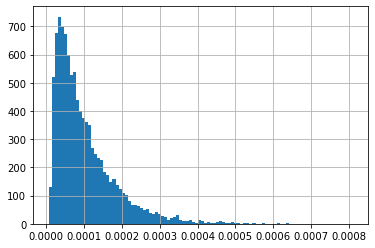

In [1272]:
print('start')
currentDT1 = dtt.datetime.now()
print (str(currentDT1))

draws_A_Up = drawfromp(1, 100 + (0.5 - 0.5) * 0.01, 100, 0.01, 0.5, 0.01, 0)
pd.Series(draws_A_Up).hist(bins=100)

print('end')
currentDT2 = dtt.datetime.now()
print (str(currentDT2))

print (str(currentDT2 - currentDT1))

In [1275]:
print('start')
currentDT1 = dtt.datetime.now()
print (str(currentDT1))

print(st.geninvgauss.fit(draws_A_Up, floc=0))

print('end')
currentDT2 = dtt.datetime.now()
print (str(currentDT2))

print (str(currentDT2 - currentDT1))

start
2020-09-24 19:08:28.613623
(0.3798032598314323, 1.2331630887499871, 0, 5.967244151033623e-05)
end
2020-09-24 19:08:29.344323
0:00:00.730700


In [610]:
# def invprob(ud, s0, s, α, η, σ, μ, n=1000, printflag=False):
#     '''invprob(ud, s0, s, α, η, σ, μ, n) solves the equation
#     Pup(t) / Pup(1) (or Pdown(t) / Pdown(1))  = p;
#     so for a random p such that 0 <= p <= 1 we find
#     the expected time of a price change for the sign given'''
#     mprobt = partial(nprobw, ud, s0, s, α, η, σ, μ)
#     mprobt1 = mprobt(1)
#     ts = []
#     vals = np.linspace(0, (1 - 1 / n), n)
#     for p in vals:
#         def groot(t):
#             return np.round(mprobt(t)/mprobt1 - p, decimals=6)
#         sol = optimize.root_scalar(groot, bracket=[0, 1], method='brentq')
#         tp = sol.root
#         ts = ts + [tp]
#     ts = pd.Series(ts)
#     p, b, loc, scale = st.geninvgauss.fit(ts, scale=((α / s0) / σ) ** 2)
#     if printflag:
#         qtls = np.array([0.01, 0.10, 0.25, 0.50, 0.75, 0.90, 0.99, 0.999])
#         dfq = pd.DataFrame(ts.quantile(qtls))
#         dfq.columns = ['From P']
#         dfq['GIG'] = [st.geninvgauss.ppf(q, p, b, loc, scale) for q in qtls]
#         print(dfq)
#     return [p, b, loc, scale]

In [769]:
qtls_def = np.linspace(0, 0.90, 10)

In [1282]:
def invprob(ud, sud, s, α, η, σ, μ, qtls=qtls_def, print_flag=False):
    '''invprob(ud, s0, s, α, η, σ, μ, n) solves the equation
    Pup(t) / Pup(1) (or Pdown(t) / Pdown(1))  = p;
    so for a random p such that 0 <= p <= 1 we find
    the expected time of a price change for the sign given'''
    cont_flag =  - ud * sud
    s0 = s + sud * (0.5 - η) * α
    adjη = np.abs(ud + sud) * η + np.abs(ud - sud) / 2
    scl = ((α / s) / σ)**2
    adj = adjη * scl
    mprobt = partial(nprobw, ud, s0, s, α, η, σ, μ)
    mprobt1 = mprobt(1)
    ts = []
    for q in qtls:
        def groot(t):
            return np.round(mprobt(t)/mprobt1 - q, decimals=6)
        sol = optimize.root_scalar(groot, bracket=[0, 1], method='brentq')
        tp = sol.root
        ts = ts + [tp]
    ts = np.array(ts)
    x0 = np.array([-0.5, 1., 1.])
    def gig(x): #  x = [p, b, scale]; loc=0
        return np.array([st.geninvgauss.cdf(t, x[0], x[1], 0, x[2] * adj) for t in ts])
    def dist_gig(x):
        return np.linalg.norm(qtls - gig(x))
    fit_gig = optimize.minimize(fun=dist_gig, x0=x0, method='Nelder-Mead',
                                options={'disp': print_flag, 'maxiter': 2000, 'adaptive': True})
#     bounds_DE = [(-1, 1), (1e-6, 4), (0.1, 10)]
#     fit_gig_DE = optimize.differential_evolution(dist_gig, bounds=bounds_DE, popsize=50, tol=1e-2, disp=print_flag)
    p, b, scale_adj = fit_gig.x
    scale = scale_adj * adj
    dist = fit_gig.fun
    mean = scale * kv(1 + scale, b) / kv(scale, b)
    adj_mean = mean / scl
    fit_qtls = np.array([st.geninvgauss.ppf(q, p, b, 0, scale) for q in qtls])
    if print_flag:
        print(pd.DataFrame({'From P': ts, 'GIG': fit_qtls}, index=qtls))
    return pd.Series([ud, sud, cont_flag, s0, s, α, η, σ, μ, scl, adj, dist, p, b, scale, scale_adj, mean, adj_mean],
                        index=['ud', 'sud', 'Co/Al', 's0', 's', 'α', 'η', 'σ', 'μ', 'scl', 'adj', 'dist', 'p', 'b', 'scale', 'scale_adj', 'mean', 'mean_scl'])

In [1290]:
def invprobgig(ud, sud, s, α, p, b, scale, qtls=qtls_def, print_flag=False):
    '''invprob(ud, s0, s, α, η, σ, μ, n) solves the equation
    Pup(t) / Pup(1) (or Pdown(t) / Pdown(1))  = p;
    so for a random p such that 0 <= p <= 1 we find
    the expected time of a price change for the sign given'''
    fit_qtls = np.array([st.geninvgauss.ppf(q, p, b, 0, scale) for q in qtls])
    def pft(x): #  x = [η, σ, μ];
        return np.array([nprobw(ud, s + sud * (0.5 - x[0]) * α, s, α, x[0], x[1], x[2], t) /
                         nprobw(ud, s + sud * (0.5 - x[0]) * α, s, α, x[0], x[1], x[2], 1) for t in fit_qtls])
    def dist_gig(x):
        return np.linalg.norm(qtls - pft(x))
    x0 = np.array([0.3, 0.01, 0.])
    fit_gig = optimize.minimize(fun=dist_gig, x0=x0, method='Nelder-Mead',
                                options={'disp': print_flag, 'maxiter': 2000, 'adaptive': True})
#     bounds_DE = [(-1, 1), (1e-6, 4), (0.1, 10)]
#     fit_gig_DE = optimize.differential_evolution(dist_gig, bounds=bounds_DE, popsize=50, tol=1e-2, disp=print_flag)
    η, σ, μ = fit_gig.x
    cont_flag =  - ud * sud
    s0 = s + sud * (0.5 - η) * α
    scl = ((α / s) / σ)**2
    adjη = np.abs(ud + sud) * η + np.abs(ud - sud) / 2
    adj = adjη * scl 
    scale_adj = scale / adj
    dist = fit_gig.fun
    mean = scale * kv(1 + scale, b) / kv(scale, b)
    adj_mean = mean / scl
    if print_flag:
        mprobt = partial(nprobw, ud, s0, s, α, η, σ, μ)
        mprobt1 = mprobt(1)
        ts = []
        for q in qtls:
            def groot(t):
                return np.round(mprobt(t)/mprobt1 - q, decimals=6)
            sol = optimize.root_scalar(groot, bracket=[0, 1], method='brentq')
            tp = sol.root
            ts = ts + [tp]
        ts = np.array(ts)
        print(pd.DataFrame({'From P': ts, 'GIG': fit_qtls}, index=qtls))
    return pd.Series([ud, sud, cont_flag, s0, s, α, η, σ, μ, scl, adj, dist, p, b, scale, scale_adj, mean, adj_mean],
                        index=['ud', 'sud', 'Co/Al', 's0', 's', 'α', 'η', 'σ', 'μ', 'scl', 'adj', 'dist', 'p', 'b', 'scale', 'scale_adj', 'mean', 'mean_scl'])

In [1285]:
print('start')
currentDT1 = dtt.datetime.now()
print (str(currentDT1))

ud = +1
s = 100
α = 0.01
η = 0.5
σ = 0.01
μ = 0
sud = +1
df = invprob(ud, sud, s, α, η, σ, μ, print_flag=True)

print('end')
currentDT2 = dtt.datetime.now()
print (str(currentDT2))

print (str(currentDT2 - currentDT1))
df

start
2020-09-25 16:53:40.565772
Optimization terminated successfully.
         Current function value: 0.004259
         Iterations: 124
         Function evaluations: 229
       From P       GIG
0.0  0.000000  0.000000
0.1  0.000026  0.000026
0.2  0.000037  0.000037
0.3  0.000048  0.000048
0.4  0.000061  0.000061
0.5  0.000076  0.000076
0.6  0.000094  0.000094
0.7  0.000117  0.000117
0.8  0.000150  0.000150
0.9  0.000206  0.000208
end
2020-09-25 16:53:41.451258
0:00:00.885486


ud             1.000000
sud            1.000000
Co/Al         -1.000000
s0           100.000000
s            100.000000
α              0.010000
η              0.500000
σ              0.010000
μ              0.000000
scl            0.000100
adj            0.000100
dist           0.004259
p              0.371050
b              1.166569
scale          0.000059
scale_adj      0.585022
mean           0.000080
mean_scl       0.803796
dtype: float64

In [1291]:
print('start')
currentDT1 = dtt.datetime.now()
print (str(currentDT1))

ud = +1
s = 100
μ = 0
sud = +1
df = invprobgig(ud, sud, s, α, 0.371050, 1.166569, 0.585022 * 0.0001, print_flag=True)

print('end')
currentDT2 = dtt.datetime.now()
print (str(currentDT2))

print (str(currentDT2 - currentDT1))
df

start
2020-09-25 16:57:57.616001
Optimization terminated successfully.
         Current function value: 0.004330
         Iterations: 73
         Function evaluations: 139
       From P       GIG
0.0  0.000000  0.000000
0.1  0.000026  0.000026
0.2  0.000037  0.000037
0.3  0.000048  0.000048
0.4  0.000061  0.000061
0.5  0.000076  0.000076
0.6  0.000094  0.000094
0.7  0.000117  0.000117
0.8  0.000150  0.000150
0.9  0.000206  0.000208
end
2020-09-25 16:57:57.719434
0:00:00.103433


ud             1.000000
sud            1.000000
Co/Al         -1.000000
s0            99.999997
s            100.000000
α              0.010000
η              0.500294
σ              0.010004
μ              0.000809
scl            0.000100
adj            0.000100
dist           0.004330
p              0.371050
b              1.166569
scale          0.000059
scale_adj      0.585199
mean           0.000080
mean_scl       0.804513
dtype: float64

In [1188]:
print('start')
currentDT1 = dtt.datetime.now()
print (str(currentDT1))

ud = +1
s = 100
α = 0.01
η = 0.01
σ = 0.01
μ = 0
sud = +1
df = invprob(ud, sud, s, α, η, σ, μ, η)

print('end')
currentDT2 = dtt.datetime.now()
print (str(currentDT2))

print (str(currentDT2 - currentDT1))
df

start
2020-09-24 11:46:48.908574
end
2020-09-24 11:46:49.822250
0:00:00.913676


ud           1.000000e+00
sud          1.000000e+00
Co/Al       -1.000000e+00
s0           1.000049e+02
s            1.000000e+02
α            1.000000e-02
η            1.000000e-02
σ            1.000000e-02
μ            0.000000e+00
scl          9.999020e-05
adj          9.999020e-07
dist         1.561900e-03
p           -5.044321e-01
b            1.761581e-02
scale        2.288907e-06
scale_adj    2.289132e+00
mean         3.124745e-05
mean_scl     3.125051e-01
dtype: float64

In [1190]:
height_def = 7
aspect_def = 1.5

In [1189]:
print('start')
currentDT1 = dtt.datetime.now()
print (str(currentDT1))

tbl_eta = np.linspace(0.01, 0.50, 50)
s = 100
α = 0.01
σ = 0.01
μ = 0

chg_eta_A_Up = pd.DataFrame({η: invprob(+1, +1, s, α, η, σ, μ, 2*η) for η in tbl_eta}).transpose()
print('chg_eta_A_Up')
chg_eta_A_Up.to_csv('chg_eta_A_Up.csv', index=False)
print (str(dtt.datetime.now()))
chg_eta_A_Down = pd.DataFrame({η: invprob(-1, -1, s, α, η, σ, μ, 2*η) for η in tbl_eta}).transpose()
print('chg_eta_A_Down')
chg_eta_A_Down.to_csv('chg_eta_A_Down.csv', index=False)
print (str(dtt.datetime.now()))
chg_eta_C_Up = pd.DataFrame({η: invprob(+1, -1, s, α, η, σ, μ, 1) for η in tbl_eta}).transpose()
print('chg_eta_C_Up')
chg_eta_C_Up.to_csv('chg_eta_C_Up.csv', index=False)
print (str(dtt.datetime.now()))
chg_eta_C_Down = pd.DataFrame({η: invprob(-1, +1, s, α, η, σ, μ, 1) for η in tbl_eta}).transpose()
print('chg_eta_C_Down')
chg_eta_C_Down.to_csv('chg_eta_C_Down.csv', index=False)
print (str(dtt.datetime.now()))

chg_eta = pd.concat([chg_eta_A_Up, chg_eta_A_Down, chg_eta_C_Up, chg_eta_C_Down])
print('chg_eta')

del(s)
del(α)
del(σ)
del(μ)

print('end')
currentDT2 = dtt.datetime.now()
print (str(currentDT2))

print (str(currentDT2 - currentDT1))

start
2020-09-24 11:46:56.631926
chg_eta_A_Up
2020-09-24 11:47:40.548554
chg_eta_A_Down
2020-09-24 11:48:26.594699
chg_eta_C_Up
2020-09-24 11:49:12.464867
chg_eta_C_Down
2020-09-24 11:49:59.398490
chg_eta
end
2020-09-24 11:49:59.399350
0:03:02.767424


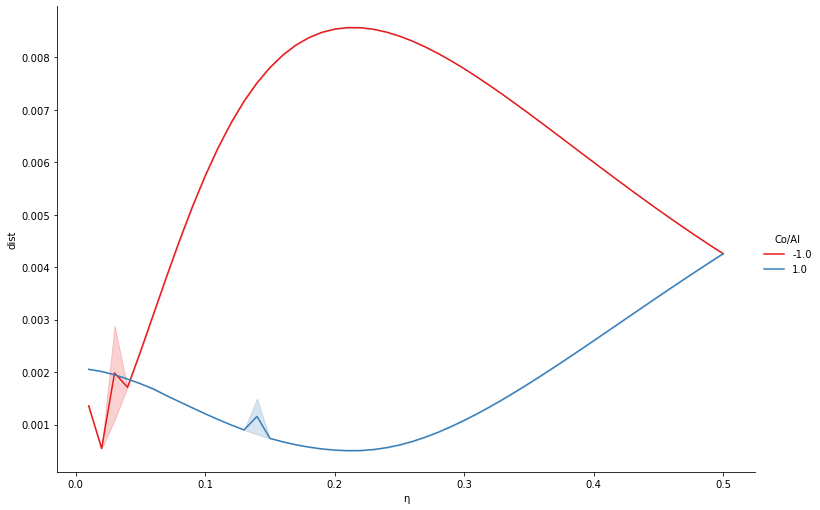

In [1191]:
sns.relplot(x='η', y='dist', hue='Co/Al', data=chg_eta, kind='line', palette='Set1', height=height_def, aspect=aspect_def);

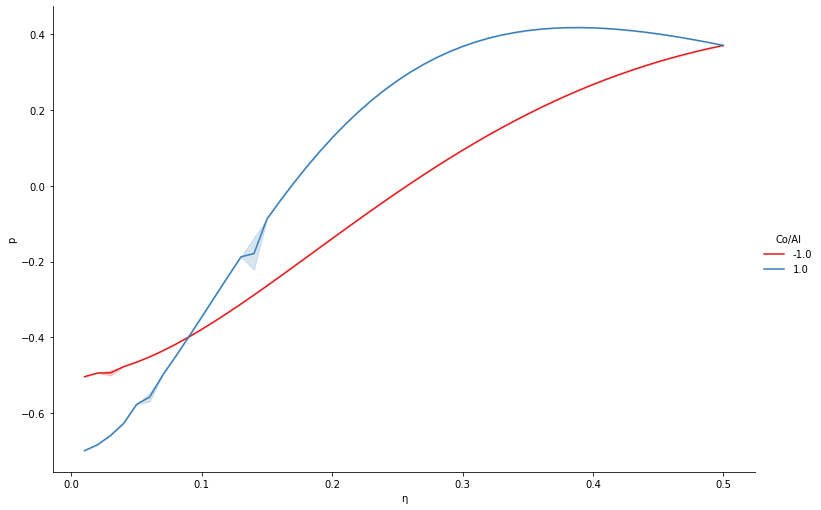

In [1192]:
sns.relplot(x='η', y='p', hue='Co/Al', data=chg_eta, kind='line', palette='Set1', height=height_def, aspect=aspect_def);

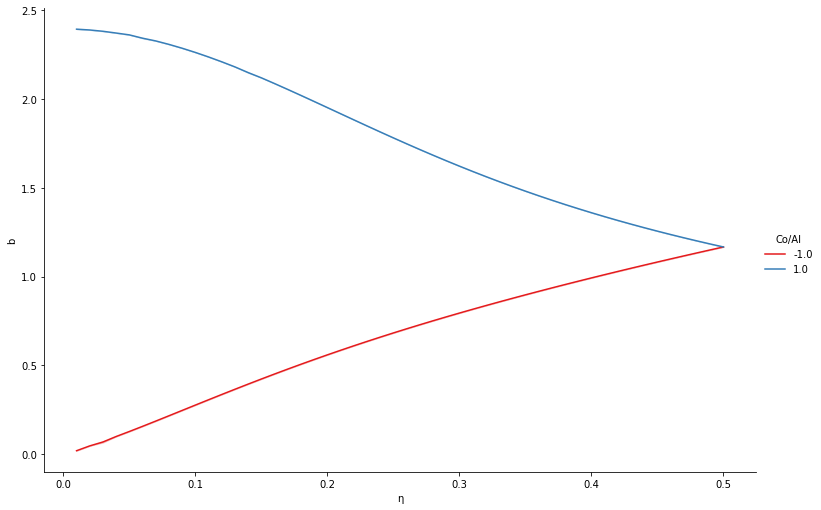

In [1193]:
sns.relplot(x='η', y='b', hue='Co/Al', data=chg_eta, kind='line', palette='Set1', height=height_def, aspect=aspect_def);

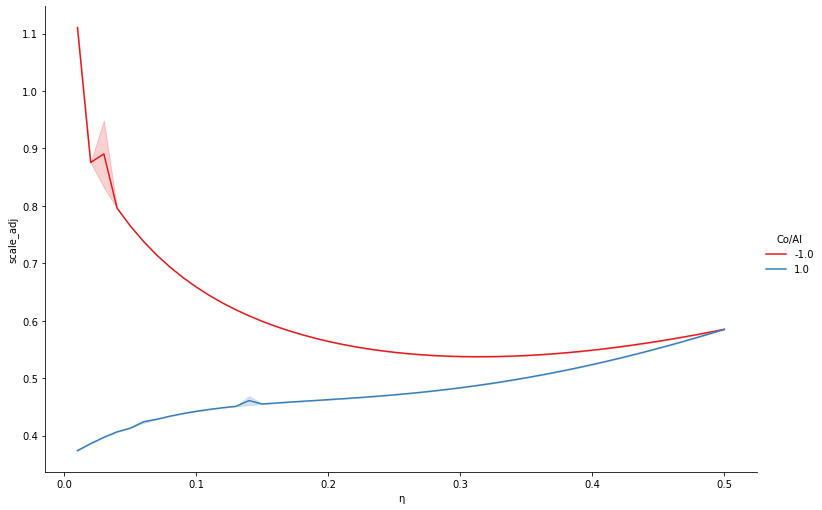

In [1194]:
sns.relplot(x='η', y='scale_adj', hue='Co/Al', data=chg_eta, kind='line', palette='Set1', height=height_def, aspect=aspect_def);

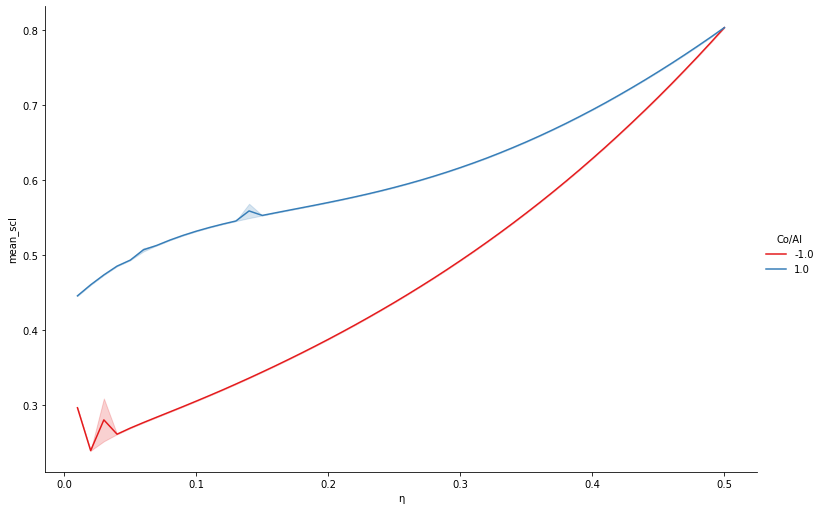

In [1195]:
sns.relplot(x='η', y='mean_scl', hue='Co/Al', data=chg_eta, kind='line', palette='Set1', height=height_def, aspect=aspect_def);

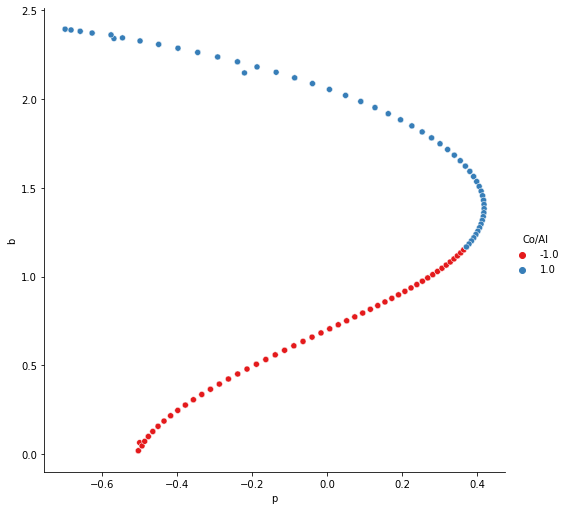

In [1201]:
sns.relplot(x='p', y='b', hue='Co/Al', data=chg_eta, palette='Set1', height=height_def, aspect=1);

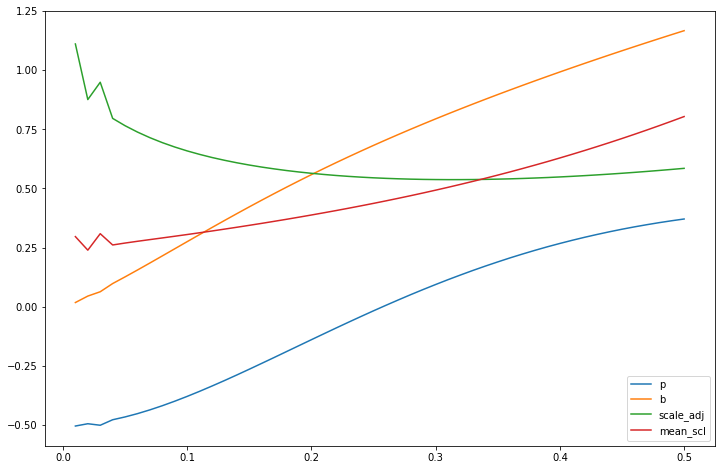

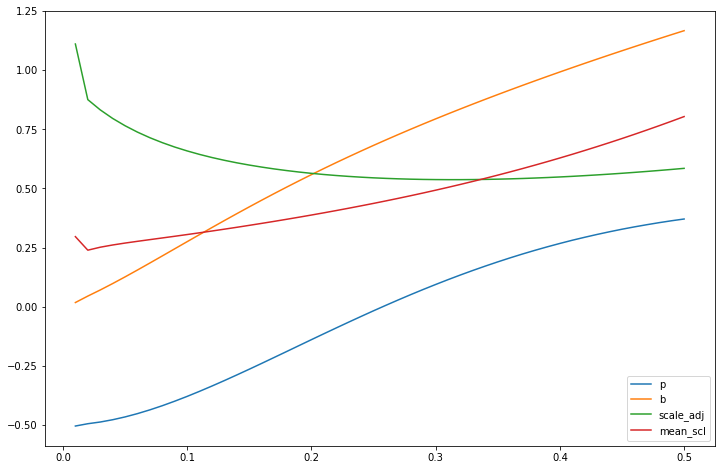

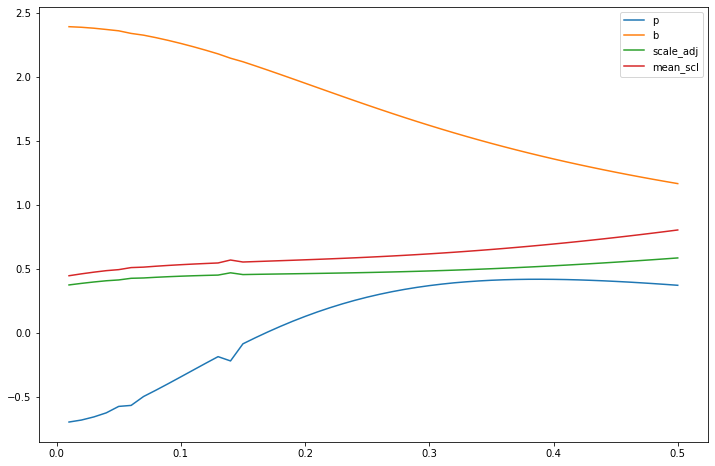

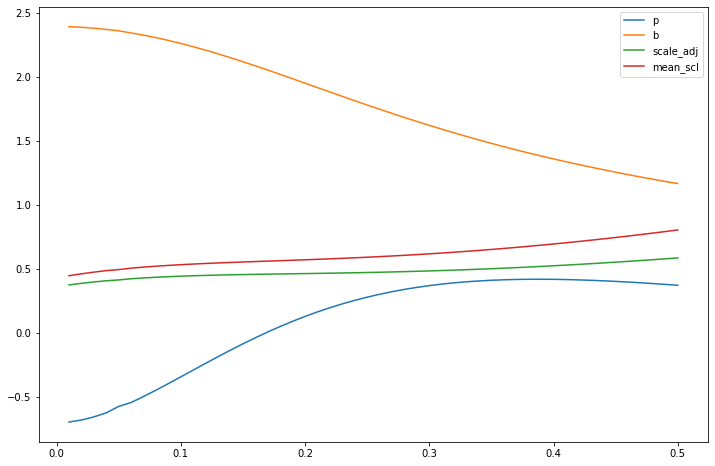

In [1197]:
chg_eta_A_Up[['p', 'b', 'scale_adj', 'mean_scl']].plot(figsize=(12, 8));
chg_eta_A_Down[['p', 'b', 'scale_adj', 'mean_scl']].plot(figsize=(12, 8));
chg_eta_C_Up[['p', 'b', 'scale_adj', 'mean_scl']].plot(figsize=(12, 8));
chg_eta_C_Down[['p', 'b', 'scale_adj', 'mean_scl']].plot(figsize=(12, 8));

In [1199]:
print('start')
currentDT1 = dtt.datetime.now()
print (str(currentDT1))

s = 100
# tbl_alpha = np.array([0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1])
# tbl_eta = np.linspace(0.05, 0.50, 10)
# tbl_vol = np.array([0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1])
# tbl_mu = np.array([-1., -0.5, -0.1, -0.01, 0, +0.01, +0.1, +0.5, +1.])
tbl_alpha = np.array([0.0025, 0.005, 0.01, 0.02])
tbl_eta = np.array([0.01, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50])
tbl_vol = np.array([0.0025, 0.005, 0.01, 0.02])
μ = 0

chg_A_Up = pd.DataFrame({(α, η, σ): invprob(+1, +1, s, α, η, σ, μ, 2*η) for α in tbl_alpha for η in tbl_eta for σ in tbl_vol}).transpose()
print('chg_A_Up')
chg_A_Up.to_csv('chg_A_Up.csv', index=False)
print (str(dtt.datetime.now()))
chg_A_Down = pd.DataFrame({(α, η, σ): invprob(-1, -1, s, α, η, σ, μ, 2*η) for α in tbl_alpha for η in tbl_eta for σ in tbl_vol}).transpose()
print('chg_A_Down')
chg_A_Down.to_csv('chg_A_Down.csv', index=False)
print (str(dtt.datetime.now()))
chg_C_Up = pd.DataFrame({(α, η, σ): invprob(+1, -1, s, α, η, σ, μ, 1) for α in tbl_alpha for η in tbl_eta for σ in tbl_vol}).transpose()
print('chg_C_Up')
chg_C_Up.to_csv('chg_C_Up.csv', index=False)
print (str(dtt.datetime.now()))
chg_C_Down = pd.DataFrame({(α, η, σ): invprob(-1, +1, s, α, η, σ, μ, 1) for α in tbl_alpha for η in tbl_eta for σ in tbl_vol}).transpose()
print('chg_C_Down')
chg_C_Down.to_csv('chg_C_Down.csv', index=False)
print (str(dtt.datetime.now()))

chgs = pd.concat([chg_A_Up, chg_A_Down, chg_C_Up, chg_C_Down])
print('chgs')

del(s)
del(μ)

print('end')
currentDT2 = dtt.datetime.now()
print (str(currentDT2))

print (str(currentDT2 - currentDT1))

start
2020-09-24 11:54:50.931726
chg_A_Up
2020-09-24 11:57:37.893510
chg_A_Down
2020-09-24 12:00:29.816844
chg_C_Up
2020-09-24 12:03:18.830316
chg_C_Down
2020-09-24 12:06:28.730341
chgs
end
2020-09-24 12:06:28.733409
0:11:37.801683


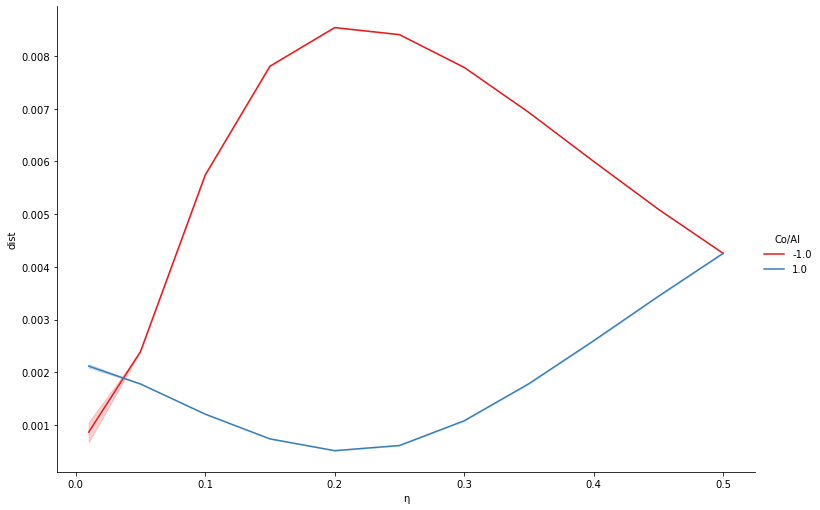

In [1202]:
sns.relplot(x='η', y='dist', hue='Co/Al', data=chgs, kind='line', palette='Set1', height=height_def, aspect=aspect_def);

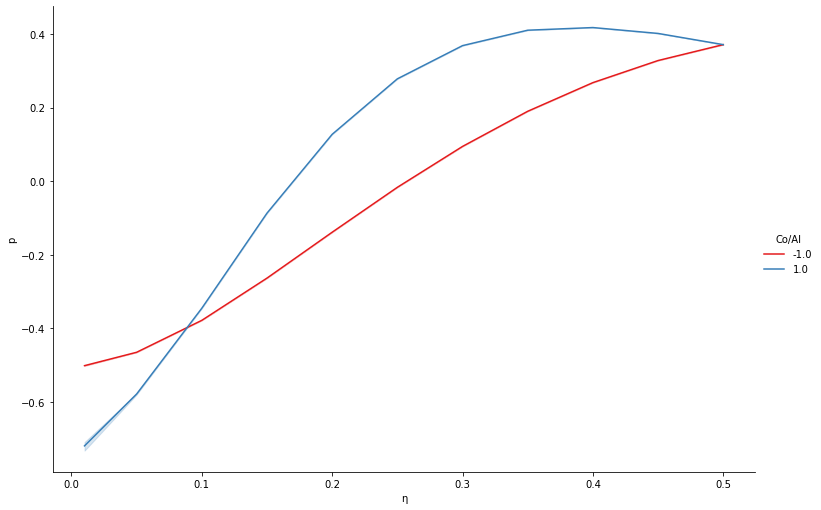

In [1203]:
sns.relplot(x='η', y='p', hue='Co/Al', data=chgs, kind='line', palette='Set1', height=height_def, aspect=aspect_def);

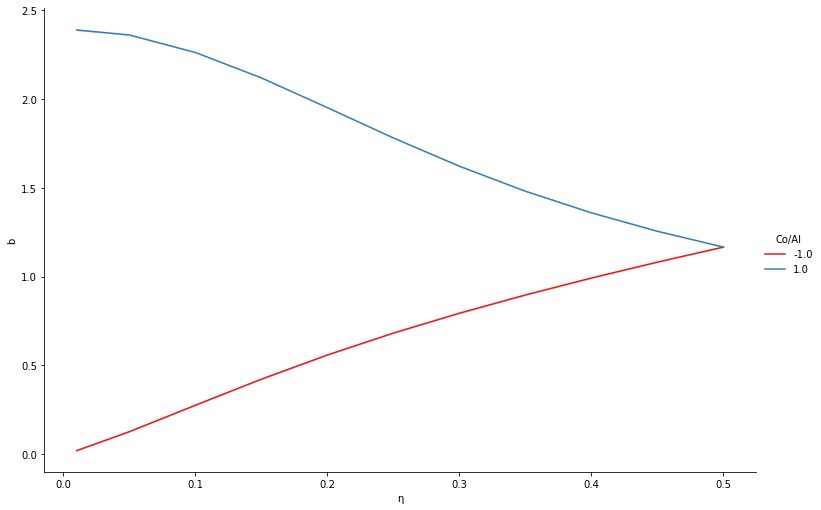

In [1204]:
sns.relplot(x='η', y='b', hue='Co/Al', data=chgs, kind='line', palette='Set1', height=height_def, aspect=aspect_def);

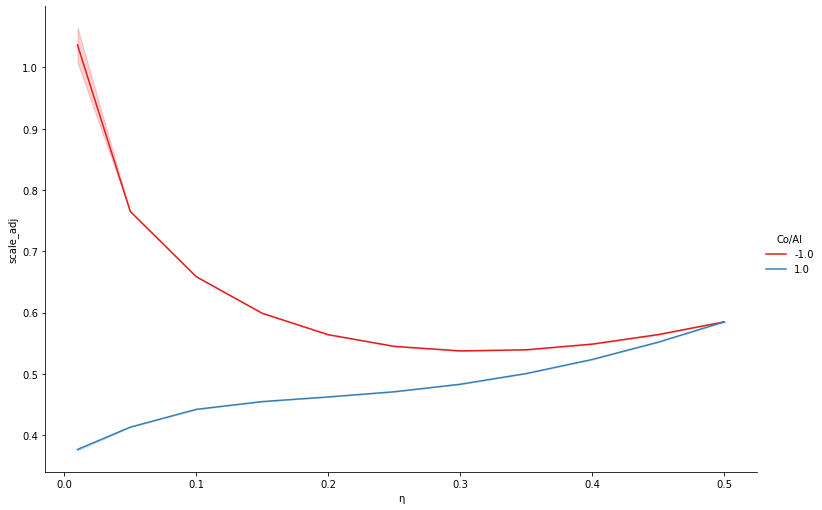

In [1205]:
sns.relplot(x='η', y='scale_adj', hue='Co/Al', data=chgs, kind='line', palette='Set1', height=height_def, aspect=aspect_def);

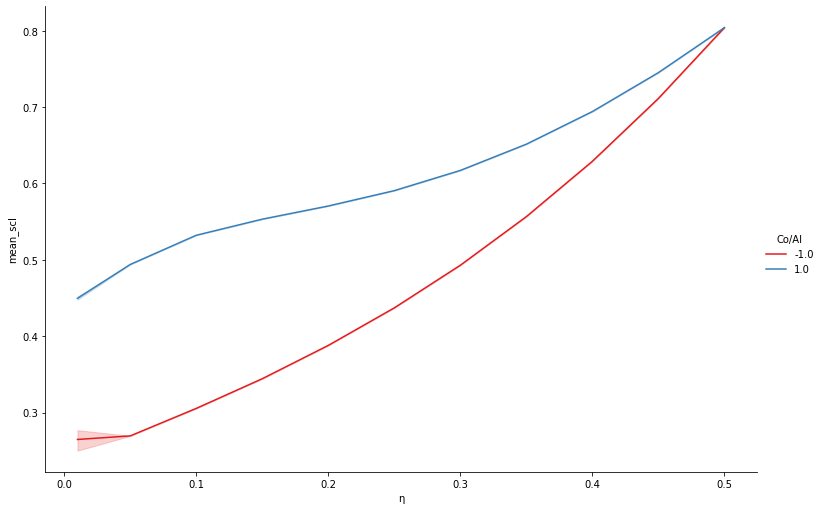

In [1207]:
sns.relplot(x='η', y='mean_scl', hue='Co/Al', data=chgs, kind='line', palette='Set1', height=height_def, aspect=aspect_def);

In [1264]:
print('start')
currentDT1 = dtt.datetime.now()
print (str(currentDT1))

s = 100
α = 0.002
tbl_eta = np.linspace(0.05, 0.50, 50)
σ = 0.01
μ = 0.10* (12 * 9)

chg_eta_mu_A_Up = pd.DataFrame({η: invprob(+1, +1, s, α, η, σ, μ, 2*η) for η in tbl_eta}).transpose()
print('chg_eta_mu_A_Up')
chg_eta_mu_A_Up.to_csv('chg_eta_mu_A_Up.csv', index=False)
print (str(dtt.datetime.now()))
chg_eta_mu_A_Down = pd.DataFrame({η: invprob(-1, -1, s, α, η, σ, μ, 2*η) for η in tbl_eta}).transpose()
print('chg_eta_mu_A_Down')
chg_eta_mu_A_Down.to_csv('chg_eta_mu_A_Down.csv', index=False)
print (str(dtt.datetime.now()))
chg_eta_mu_C_Up = pd.DataFrame({η: invprob(+1, -1, s, α, η, σ, μ, 1) for η in tbl_eta}).transpose()
print('chg_eta_mu_C_Up')
chg_eta_mu_C_Up.to_csv('chg_eta_mu_C_Up.csv', index=False)
print (str(dtt.datetime.now()))
chg_eta_mu_C_Down = pd.DataFrame({η: invprob(-1, +1, s, α, η, σ, μ, 1) for η in tbl_eta}).transpose()
print('chg_eta_mu_C_Down')
chg_eta_mu_C_Down.to_csv('chg_eta_mu_C_Down.csv', index=False)
print (str(dtt.datetime.now()))

chg_eta_mu = pd.concat([chg_eta_mu_A_Up, chg_eta_mu_A_Down, chg_eta_mu_C_Up, chg_eta_mu_C_Down])
print('chg_mu')

del(s)
del(α)
del(σ)
del(μ)

print('end')
currentDT2 = dtt.datetime.now()
print (str(currentDT2))

print (str(currentDT2 - currentDT1))

start
2020-09-24 15:16:59.478653
chg_eta_mu_A_Up
2020-09-24 15:17:50.473955
chg_eta_mu_A_Down
2020-09-24 15:18:40.855506
chg_eta_mu_C_Up
2020-09-24 15:19:33.549648
chg_eta_mu_C_Down
2020-09-24 15:20:30.916735
chg_mu
end
2020-09-24 15:20:30.917475
0:03:31.438822


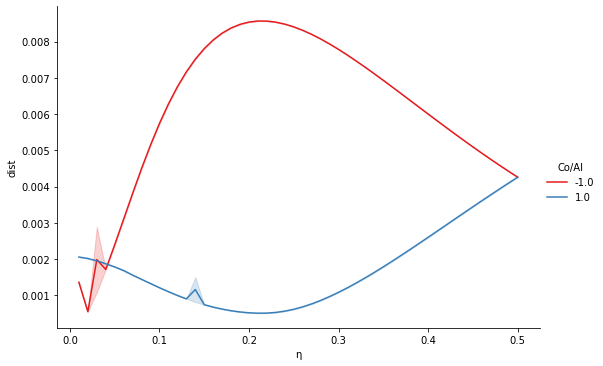

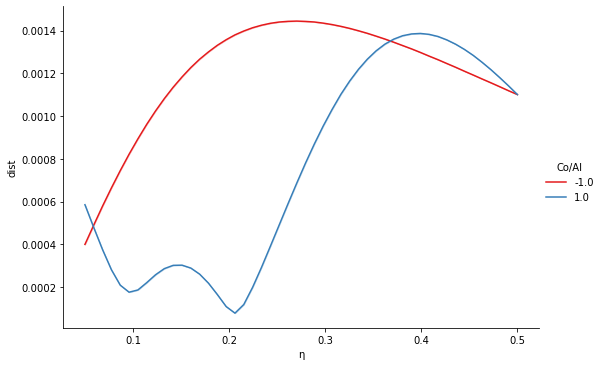

In [1265]:
sns.relplot(x='η', y='dist', hue='Co/Al', data=chg_eta, kind='line', palette='Set1', height=5, aspect=aspect_def);
sns.relplot(x='η', y='dist', hue='Co/Al', data=chg_eta_mu, kind='line', palette='Set1', height=5, aspect=aspect_def);

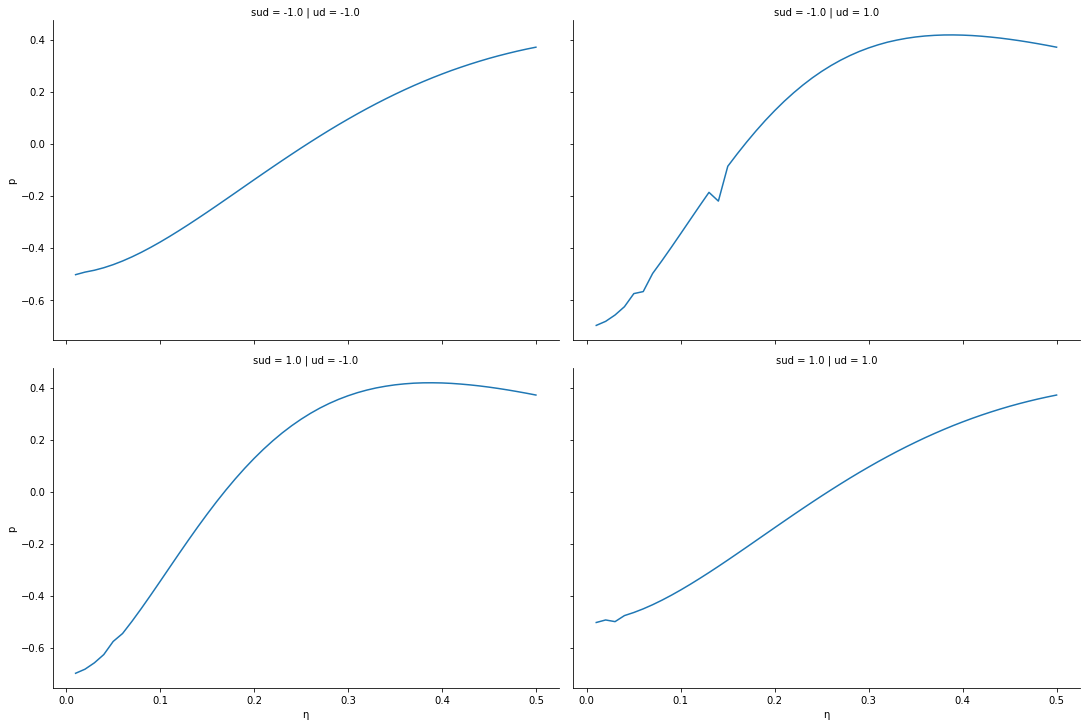

In [1266]:
sns.relplot(x='η', y='p', row='sud', col='ud', data=chg_eta, kind='line', palette='Set1', height=5, aspect=aspect_def);

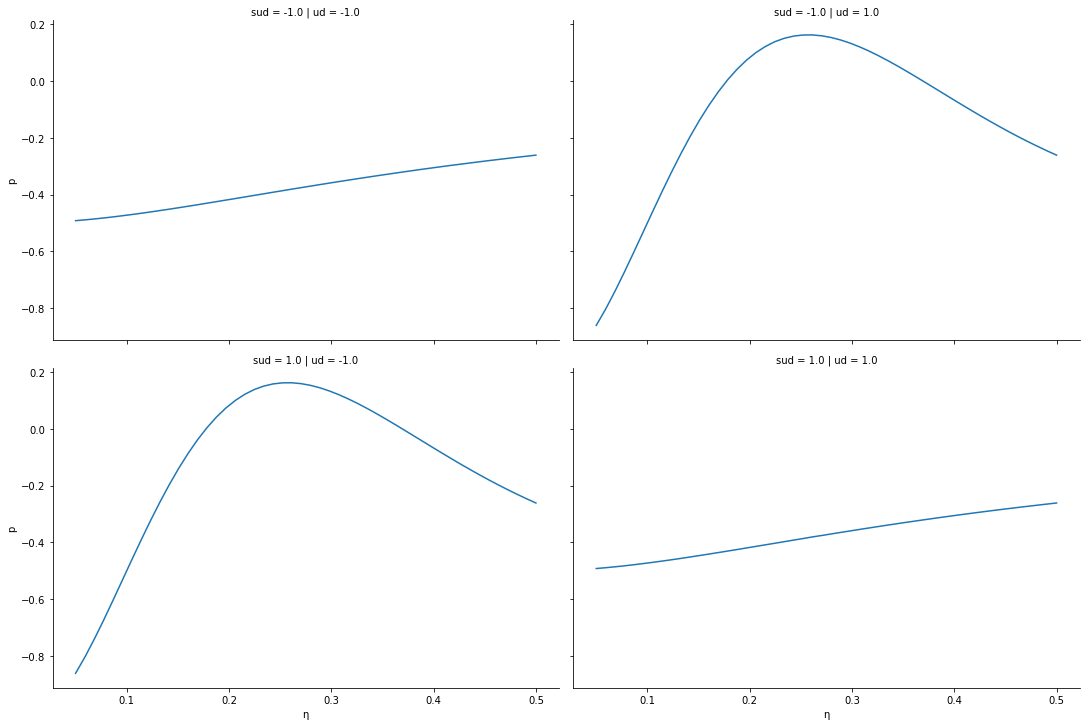

In [1267]:
sns.relplot(x='η', y='p', row='sud', col='ud', data=chg_eta_mu, kind='line', palette='Set1', height=5, aspect=aspect_def);

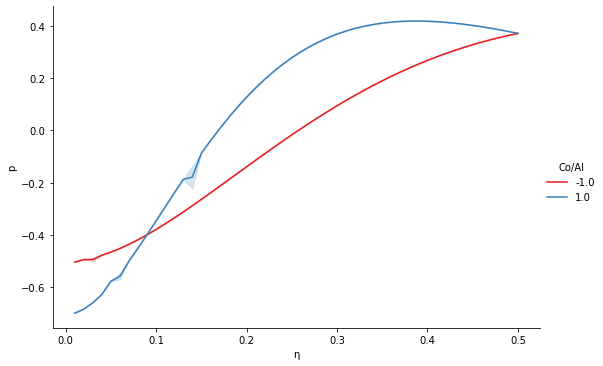

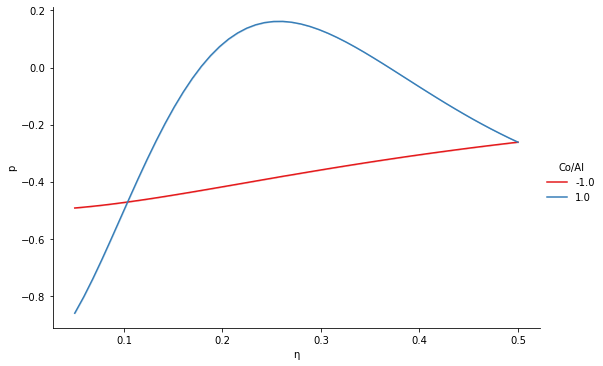

In [1268]:
sns.relplot(x='η', y='p', hue='Co/Al', data=chg_eta, kind='line', palette='Set1', height=5, aspect=aspect_def);
sns.relplot(x='η', y='p', hue='Co/Al', data=chg_eta_mu, kind='line', palette='Set1', height=5, aspect=aspect_def);

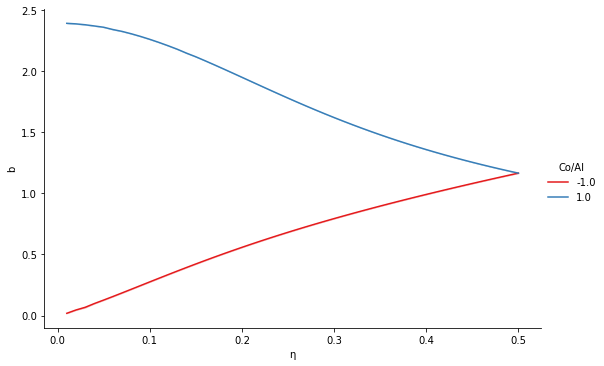

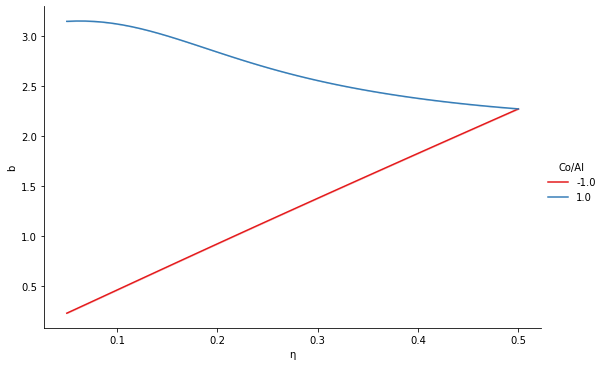

In [1269]:
sns.relplot(x='η', y='b', hue='Co/Al', data=chg_eta, kind='line', palette='Set1', height=5, aspect=aspect_def);
sns.relplot(x='η', y='b', hue='Co/Al', data=chg_eta_mu, kind='line', palette='Set1', height=5, aspect=aspect_def);

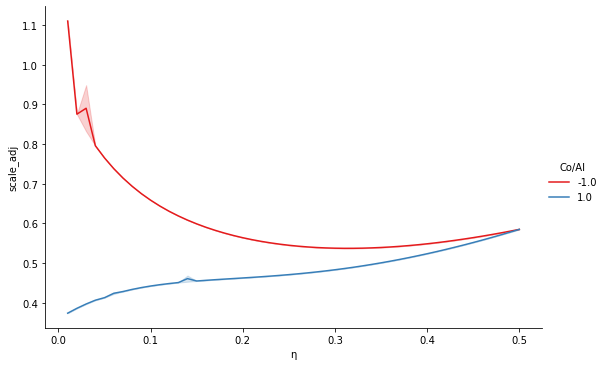

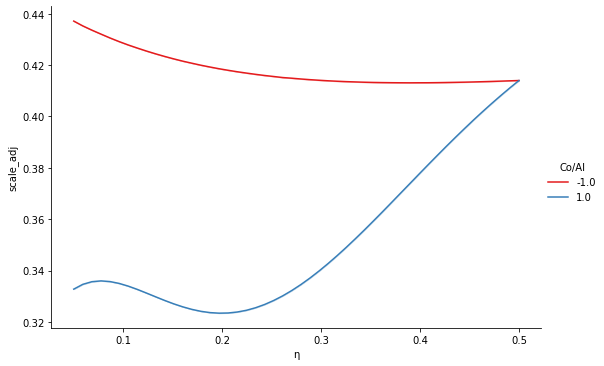

In [1270]:
sns.relplot(x='η', y='scale_adj', hue='Co/Al', data=chg_eta, kind='line', palette='Set1', height=5, aspect=aspect_def);
sns.relplot(x='η', y='scale_adj', hue='Co/Al', data=chg_eta_mu, kind='line', palette='Set1', height=5, aspect=aspect_def);

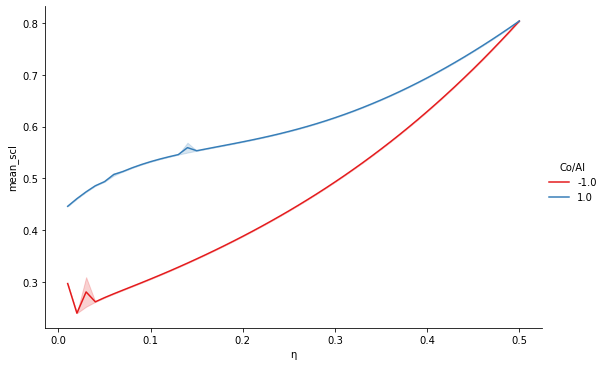

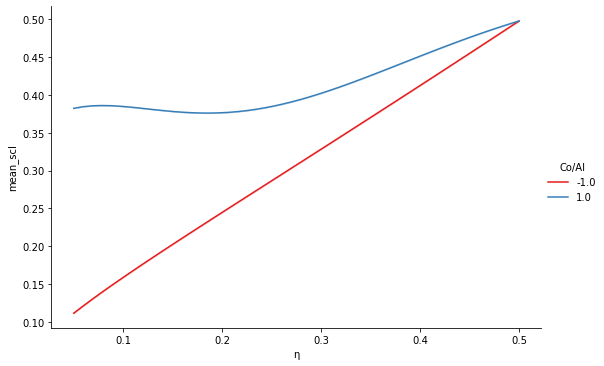

In [1271]:
sns.relplot(x='η', y='mean_scl', hue='Co/Al', data=chg_eta, kind='line', palette='Set1', height=5, aspect=aspect_def);
sns.relplot(x='η', y='mean_scl', hue='Co/Al', data=chg_eta_mu, kind='line', palette='Set1', height=5, aspect=aspect_def);

In [1249]:
print('start')
currentDT1 = dtt.datetime.now()
print (str(currentDT1))

s = 100
α = 0.002
η= 0.50
σ = 0.01
tbl_mu = np.linspace(-0.10, +0.10, 21)
μt = (60 * 9) / 5

chg_mu_A_Up = pd.DataFrame({μ: invprob(+1, +1, s, α, η, σ, μ * μt, 2*η) for μ in tbl_mu}).transpose()
print('chg_mu_A_Up')
chg_mu_A_Up.to_csv('chg_mu_A_Up.csv', index=False)
print (str(dtt.datetime.now()))
chg_mu_A_Down = pd.DataFrame({μ: invprob(-1, -1, s, α, η, σ, μ * μt, 2*η) for μ in tbl_mu}).transpose()
print('chg_mu_A_Down')
chg_mu_A_Down.to_csv('chg_mu_A_Down.csv', index=False)
print (str(dtt.datetime.now()))
chg_mu_C_Up = pd.DataFrame({μ: invprob(+1, -1, s, α, η, σ, μ * μt, 1) for μ in tbl_mu}).transpose()
print('chg_mu_C_Up')
chg_mu_C_Up.to_csv('chg_mu_C_Up.csv', index=False)
print (str(dtt.datetime.now()))
chg_mu_C_Down = pd.DataFrame({μ: invprob(-1, +1, s, α, η, σ, μ * μt, 1) for μ in tbl_mu}).transpose()
print('chg_mu_C_Down')
chg_mu_C_Down.to_csv('chg_mu_C_Down.csv', index=False)
print (str(dtt.datetime.now()))

chg_mu = pd.concat([chg_mu_A_Up, chg_mu_A_Down, chg_mu_C_Up, chg_mu_C_Down])
print('chg_mu')

del(s)
del(η)
del(α)
del(σ)

print('end')
currentDT2 = dtt.datetime.now()
print (str(currentDT2))

print (str(currentDT2 - currentDT1))

start
2020-09-24 12:50:16.420491
chg_mu_A_Up
2020-09-24 12:50:33.882656
chg_mu_A_Down
2020-09-24 12:50:51.177835
chg_mu_C_Up
2020-09-24 12:51:08.194478
chg_mu_C_Down
2020-09-24 12:51:25.226975
chg_mu
end
2020-09-24 12:51:25.228556
0:01:08.808065


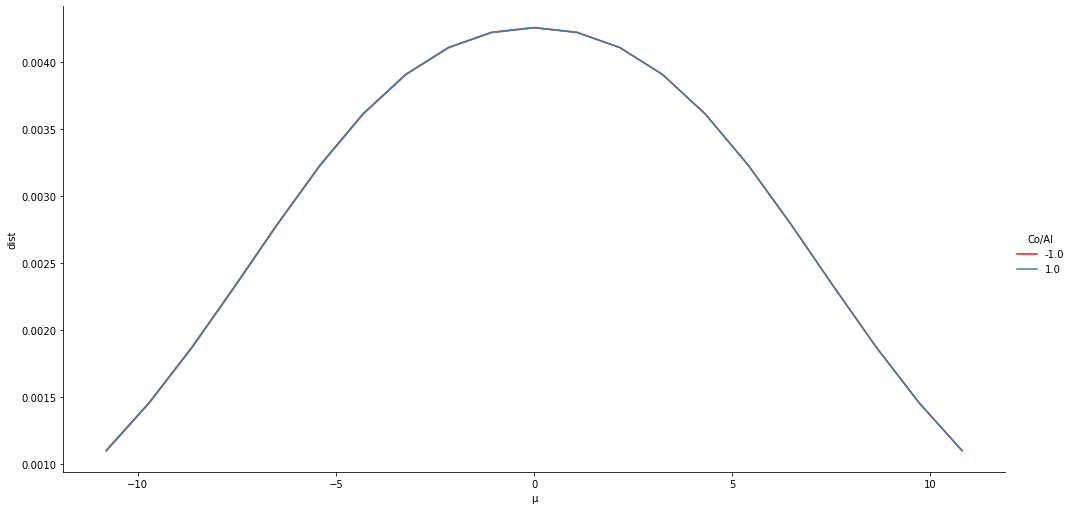

In [1250]:
sns.relplot(x='μ', y='dist', hue='Co/Al', data=chg_mu, kind='line', palette='Set1', height=height_def, aspect=2);

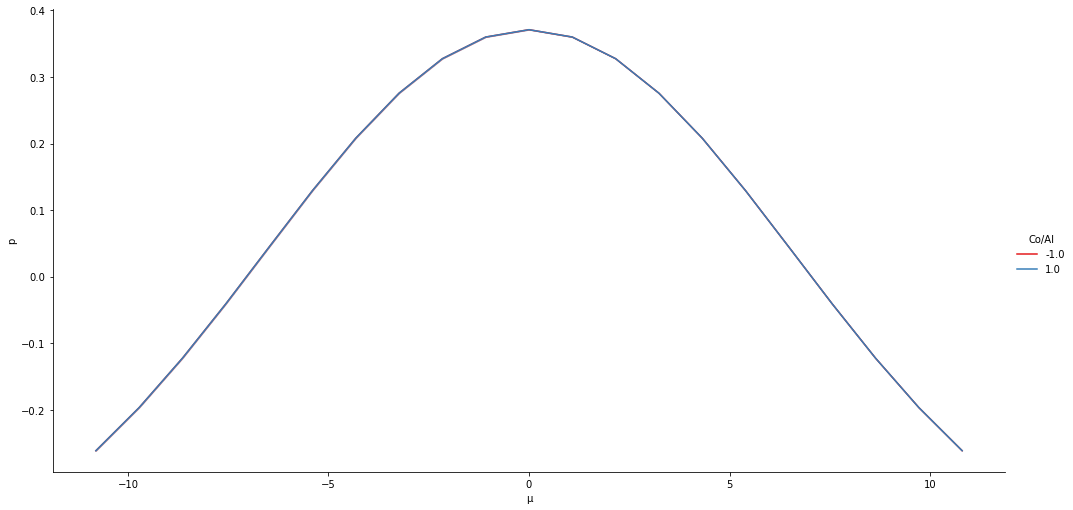

In [1251]:
sns.relplot(x='μ', y='p', hue='Co/Al', data=chg_mu, kind='line', palette='Set1', height=height_def, aspect=2);

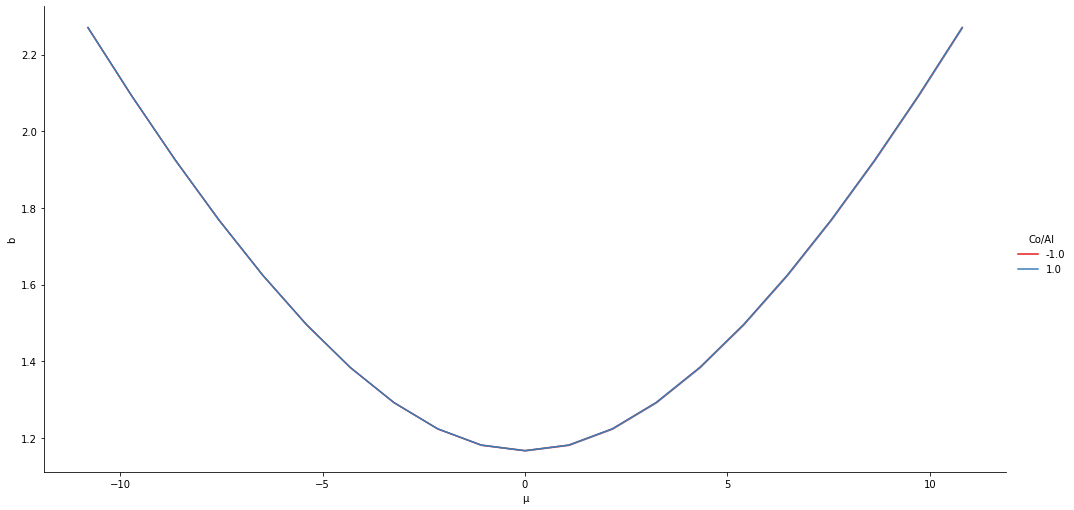

In [1252]:
sns.relplot(x='μ', y='b', hue='Co/Al', data=chg_mu, kind='line', palette='Set1', height=height_def, aspect=2);

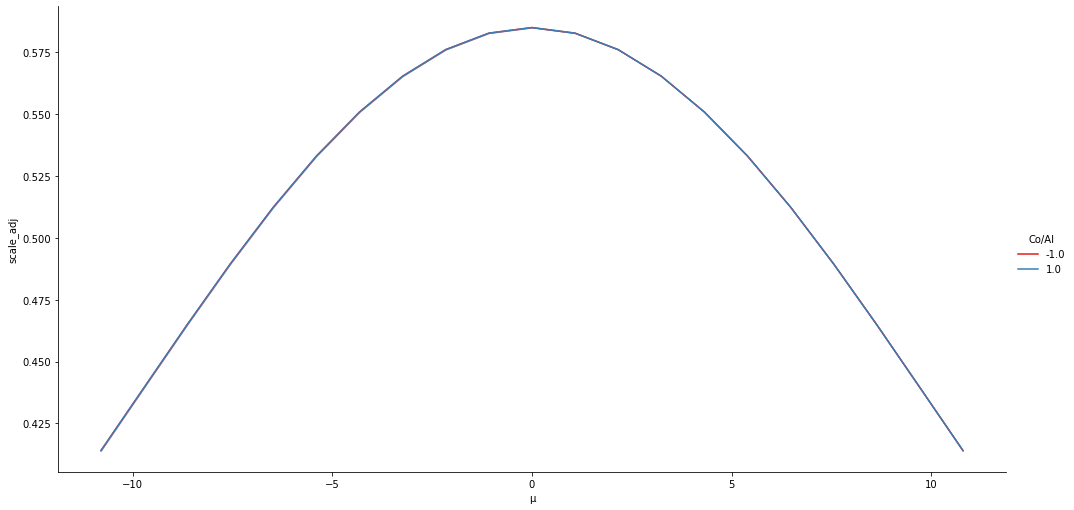

In [1253]:
sns.relplot(x='μ', y='scale_adj', hue='Co/Al', data=chg_mu, kind='line', palette='Set1', height=height_def, aspect=2);

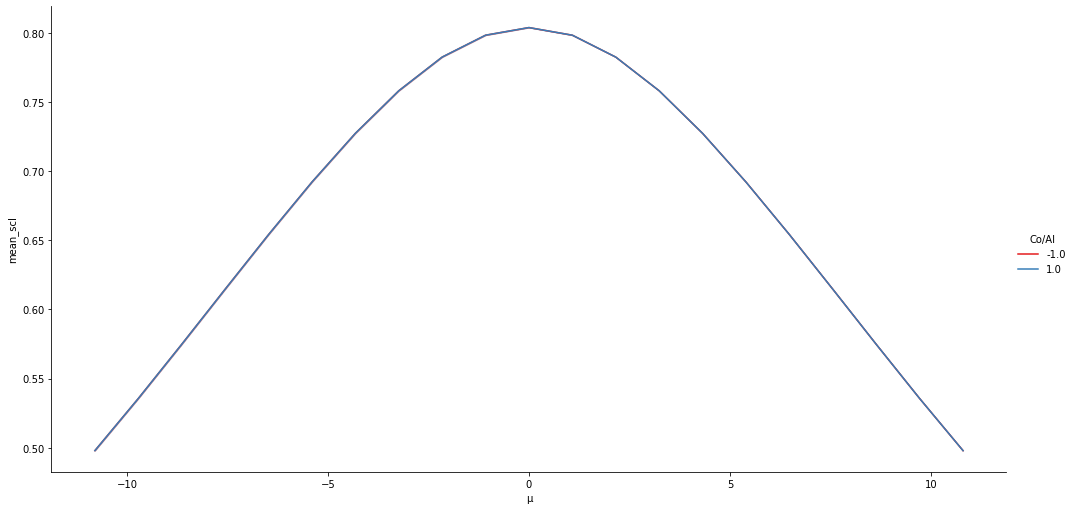

In [1254]:
sns.relplot(x='μ', y='mean_scl', hue='Co/Al', data=chg_mu, kind='line', palette='Set1', height=height_def, aspect=2);

In [8]:
def t_from_p(s0, s, α, η, σ, μ, p):
    '''t_from_p(s0, s, α, η, σ, μ, p) solves the equation
    Pup(t) + Pdown(t) = p; so for a random p such that 0 <= p <= 1 we find
    the expected time of a price change'''
    mprobtup = partial(nprobw, 1, s0, s, α, η, σ, μ)
    mprobtdown = partial(nprobw, -1, s0, s, α, η, σ, μ)
    def groot(t):
        return np.round(mprobtup(t) + mprobtdown(t) - p, decimals=6)
    sol = optimize.root_scalar(groot, bracket=[0, 1], method='brentq')
    return sol.root

In [9]:
def t_from_pud(s0, s, α, η, σ, μ, ud, p):
    '''t_from_pud(s0, s, α, η, σ, μ, ud, p) solves the equation
    Pup(t) / Pup(1) (or Pdown(t) / Pdown(1))  = p;
    so for a random p such that 0 <= p <= 1 we find
    the expected time of a price change for the sign given'''
    mprobt = partial(nprobw, ud, s0, s, α, η, σ, μ)
    def groot(t):
        return np.round(mprobt(t)/mprobt(1) - p, decimals=6)
    sol = optimize.root_scalar(groot, bracket=[0, 1], method='brentq')
    return sol.root

In [18]:
print('start')
currentDT1 = dtt.datetime.now()
print (str(currentDT1))

t50 = t_from_p(100 + (0.5 - 0.2) * 0.01, 100, 0.01, 0.5, 0.01, 0, 0.999999)
print(t50)

print('end')
currentDT2 = dtt.datetime.now()
print (str(currentDT2))

print (str(currentDT2 - currentDT1))

start
2020-09-04 14:57:58.690214
0.00118582470703125
end
2020-09-04 14:57:58.987359
0:00:00.297145


In [10]:
def cdf(s0, s, α, η, σ, μ, npts=100+1):
    grid = np.linspace(0., 0.999, npts)
    pts = pd.Series(grid, index=[t_from_p(s0, s, α, η, σ, μ, p)
                                 for p in grid])
    pts.index.name = 't'
    pts.name = 'CDF(t)'
    return pts

In [11]:
def cdfs(s0, s, α, η, σ, μ, npts=100):
    grid = np.linspace(0, 0.999, npts)
    ts = [t_from_p(s0, s, α, η, σ, μ, p) for p in grid]
    up = [nprobw(+1, s0, s, α, η, σ, μ, t) for t in ts]
    up = np.minimum(up, grid)
    pts = pd.DataFrame({'CDF(t)': grid, 'Up': up, 'Down': grid - up},
                       index=ts)
    pts.index.name = 't'
    # pts.loc[0] = [0., up[0], 1 - up[0]]
    return pts.sort_index()

In [21]:

tcdf = cdfs(100 + (0.5 - 0.25) * 0.01, 100, 0.01, 0.25, 0.01, 0)

In [22]:
def cdfsplot(s0, s, α, η, σ, μ, npts=100+1):
    df = cdfs(s0, s, α, η, σ, μ, npts)
    title = str([s0, s, α, η, σ, μ])
    df.plot(figsize=(9, 6), marker='o', title=title)

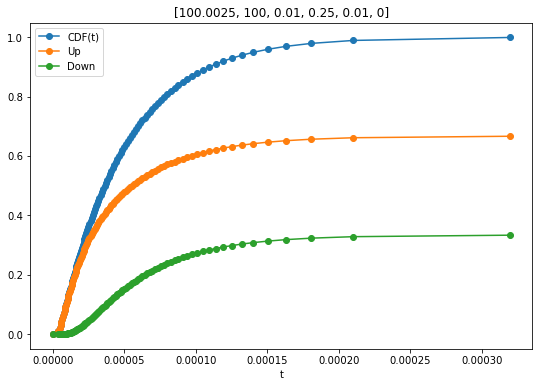

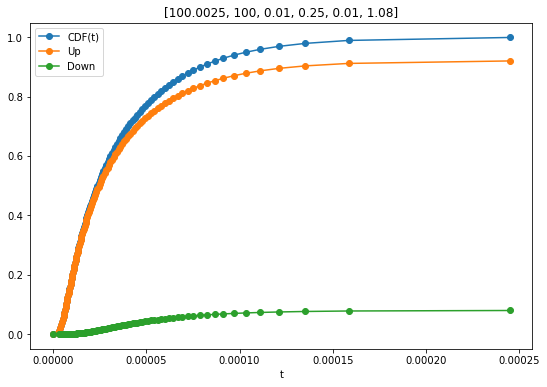

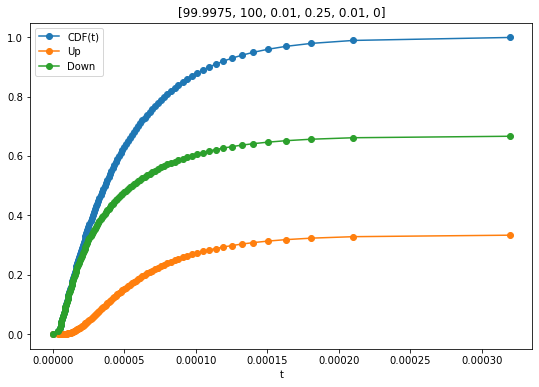

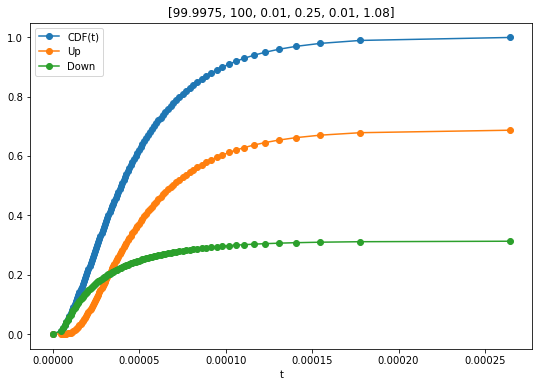

In [23]:

cdfsplot(100 + (0.5 - 0.25) * 0.01, 100, 0.01, 0.25, 0.01, 0)
# cdfsplot(100 + (0.5 - 0.25) * 0.01, 100, 0.01, 0.25, 0.015, 0)
cdfsplot(100 + (0.5 - 0.25) * 0.01, 100, 0.01, 0.25, 0.01, 0.002*9*60)
cdfsplot(100 - (0.5 - 0.25) * 0.01, 100, 0.01, 0.25, 0.01, 0)
cdfsplot(100 - (0.5 - 0.25) * 0.01, 100, 0.01, 0.25, 0.01, 0.002*9*60)

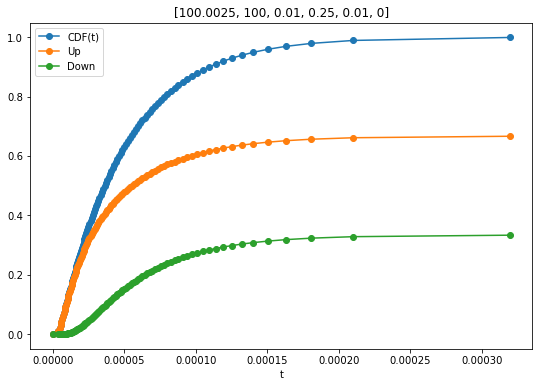

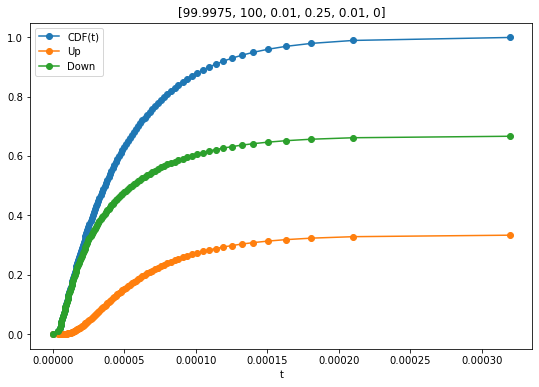

In [24]:

cdfsplot(100 + (0.5 - 0.25) * 0.01, 100, 0.01, 0.25, 0.01, 0)
cdfsplot(100 - (0.5 - 0.25) * 0.01, 100, 0.01, 0.25, 0.01, 0)

In [25]:

print('start')
currentDT1 = dtt.datetime.now()
print (str(currentDT1))

pts0 = cdf(100 + (0.5 - 0.5) * 0.01, 100, 0.01, 0.5, 0.01, 0)
pts1 = cdf(100 + (0.5 - 0.2) * 0.01, 100, 0.01, 0.2, 0.01, 0)
pts2 = cdf(100 + (0.5 - 0.5) * 0.01, 100, 0.01, 0.5, 0.01, 0.10)
pts3 = cdf(100 + (0.5 - 0.5) * 0.01, 100, 0.01, 0.5, 0.015, 0)

print('end')
currentDT2 = dtt.datetime.now()
print (str(currentDT2))

print (str(currentDT2 - currentDT1))

start
2020-09-04 14:58:26.121201
end
2020-09-04 14:58:26.249968
0:00:00.128767


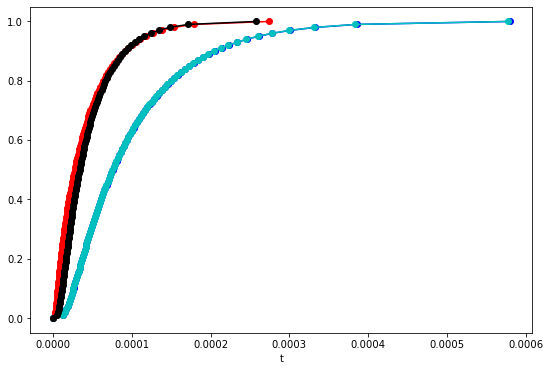

In [26]:

pts0.plot(figsize=(9, 6), color='b', marker='o');
pts1.plot(figsize=(9, 6), color='r', marker='o');
pts2.plot(figsize=(9, 6), color='c', marker='o');
pts3.plot(figsize=(9, 6), color='k', marker='o');

In [ ]:
def up_down(s0, s, α, η, σ, μ, t, p):
    '''up_down(s0, s, α, η, σ, μ, t, p) finds Pup(t) and Pdown(t) with t
    given by solving t_from_p outside the function so that
    for a random p such that 0 <= p <= 1 we choose
    the expected sign (+1 or -1) of a price change'''
    pup = nprobw(1, s0, s, α, η, σ, μ, t)
    pdown = nprobw(-1, s0, s, α, η, σ, μ, t)
    return int(2 * np.heaviside(p - pdown / (pup + pdown), 1) - 1)

In [ ]:
print('start')
currentDT1 = dtt.datetime.now()
print (str(currentDT1))

print(
      np.array(
          [up_down(100 + (0.5 - 0.5) * 0.01, 100, 0.01, 0.5, 0.01, 0, t50,
           np.random.uniform(low=0., high=1.)) for j in range(20)]))

print('end')
currentDT2 = dtt.datetime.now()
print (str(currentDT2))

print (str(currentDT2 - currentDT1))

In [ ]:
def next_move(s0, s, α, η, σ, μ):
    p = np.random.uniform(low=0., high=0.999999)
    t = t_from_p(s0, s, α, η, σ, μ, p)
    p = np.random.uniform(low=0., high=0.999999)
    ud = up_down(s0, s, α, η, σ, μ, t, p)
    return [t, ud]

In [ ]:
print('start')
currentDT1 = dtt.datetime.now()
print (str(currentDT1))

print(next_move(100 + (0.5 - 0.5) * 0.01, 100, 0.01, 0.5, 0.01, 0))

print('end')
currentDT2 = dtt.datetime.now()
print (str(currentDT2))

print (str(currentDT2 - currentDT1))

In [ ]:
def next_state_t(α, η, σ, μ, state):
    sup = state[0]
    s = state[1]
    prev_s = s + sup * (0.5 - η) * α
    p = np.random.uniform(low=0., high=0.999999)
    t = t_from_p(prev_s, s, α, η, σ, μ, p)
    p = np.random.uniform(low=0., high=0.999999)
    up = up_down(prev_s, s, α, η, σ, μ, t, p)
    alt = sup == up
    cont = sup != up
    return [[t, s + up * α, up, alt, cont], [-up, s + up * α]]

In [ ]:
def next_state(α, η, σ, μ, state):
    sup = state[0]
    s = state[1]
    prev_s = s + sup * (0.5 - η) * α
    p = np.random.uniform(low=0., high=0.999999)
    up = up_down(prev_s, s, α, η, σ, μ, 1, p)
    p = np.random.uniform(low=0., high=0.999999)
    t = t_from_pud(prev_s, s, α, η, σ, μ, up, p)
    alt = sup == up
    cont = sup != up
    return [[t, s + up * α, up, alt, cont], [-up, s + up * α]]

In [ ]:
print('start')
currentDT1 = dtt.datetime.now()
print (str(currentDT1))

print(next_state(0.01, 0.25, 0.01, 0, [+1, 100]))

print('end')
currentDT2 = dtt.datetime.now()
print (str(currentDT2))

print (str(currentDT2 - currentDT1))

In [ ]:

def simul(s, α, η, σ, μ, T):
    state = [np.random.choice([-1, +1]), s]
    df = pd.DataFrame({'dt': 0, 'P': state[1], 'Sign': 0,
                       'Al': True, 'Co': False}, index=[0])
    n = 1
    while df['dt'].sum() < T:
        row, state = next_state(α, η, σ, μ, state)
        df.loc[n] = row
        n += 1
    df['t'] = df['dt'].cumsum()
    df.set_index('t', inplace=True)
    return df

In [ ]:
print('start')
currentDT1 = dtt.datetime.now()
print (str(currentDT1))

df_simul = simul(100, 0.01, 0.25, 0.01, 0, 1)

print('end')
currentDT2 = dtt.datetime.now()
print (str(currentDT2))

print (str(currentDT2 - currentDT1))

In [ ]:

df_simul['P'].plot()

In [ ]:

def acup_qtl(df):
    df_aup = df[(df['Sign'] == +1) & (df['Al'])]['dt']
    df_cup = df[(df['Sign'] == +1) & (df['Co'])]['dt']
    df_ado = df[(df['Sign'] == -1) & (df['Al'])]['dt']
    df_cdo = df[(df['Sign'] == -1) & (df['Co'])]['dt']
    qtl_rng = np.linspace(0.01, 1.00, 100)
    df_aupq = df_aup.quantile(qtl_rng).reset_index().set_index('dt')
    df_cupq = df_cup.quantile(qtl_rng).reset_index().set_index('dt')
    df_adoq = df_ado.quantile(qtl_rng).reset_index().set_index('dt')
    df_cdoq = df_cdo.quantile(qtl_rng).reset_index().set_index('dt')
    df_aupq.columns = ['p_Al_Up']
    df_cupq.columns = ['p_Co_Up']
    df_adoq.columns = ['p_Al_Do']
    df_cdoq.columns = ['p_Co_Do']
    return [df_aupq, df_cupq, df_adoq, df_cdoq]

In [ ]:

df_quant = acup_qtl(df_simul)
pd.concat(df_quant, axis=1).interpolate().plot()

In [ ]:

def roll_H(df):
    dfc = df.copy()
    dfc['Cum_Al'] = dfc['Al'].cumsum()
    dfc['Cum_Co'] = dfc['Co'].cumsum()
    dfc['H'] = dfc['Cum_Co'] / (2 * dfc['Cum_Al'])
    return dfc['H']

In [ ]:

print(df_simul[['Al', 'Co']].sum())
df_H = roll_H(df_simul)
df_H.plot()

### Examples

In [18]:
# t_values = [1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1]
t_values = [1e-5, 1e-4, 1e-3, 1e-2]
alpha_values = [0.001, 0.01, 0.1, 1]
eta_values = [0.05, 0.2, 0.35, 0.5]
vol_values = [0.001, 0.01, 0.1]
mu_values = [0, 0.02, 0.10]

In [45]:
stat_dist([[0.4, 0.6], [0.2, 0.8]])

start
2020-08-20 18:55:09.175809
end
2020-08-20 19:10:22.697646


In [17]:
inita = np.array([[0,0],[1,1]])